## Part I: Code Your Neural Network!



## 1.1 Get the Data



### 1.1.1 File Download

In [66]:
import os, sys
import pandas as pd
import numpy as np

In [67]:
from google.colab import drive
drive.mount("/content/gdrive")


Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [68]:
train = pd.read_csv("/content/gdrive/MyDrive/data/intro_ml_2025/ml_tutorial_5_data_train.csv")
test = pd.read_csv("/content/gdrive/MyDrive/data/intro_ml_2025/ml_tutorial_5_data_test.csv")

In [69]:
train.head(5)

,x1,x2,class
0,-0.136282,3.244889,0
1,-5.305888,5.629232,0
2,-4.147647,-0.226319,1
3,-2.170794,3.946986,0
4,-5.555908,1.155239,0


### 1.1.2 Split Signal vs Background

In [70]:
# Split training data into signal and background
sig = train[train["class"]==1]
bkg = train[train["class"]== 0]

### 1.1.3 Dataframe to NumPy

In [71]:
#from sklearn.model_selection import train_test_split
inputs = ['x1', 'x2']
X_train = train[inputs]
y_train = train['class']
print("X_train.shape:", X_train.shape)
print("y_train.shape:", y_train.shape)

X_test = test[inputs]
y_test = test['class']

X_train.shape: (320, 2)
y_train.shape: (320,)


## 1.2 Functions

### 1.2.1 Weighted Sum

In [72]:
def z(weights,activation,biases):
    return np.dot(activation,weights)+biases

### 1.2.2 Activation Functions and Derivatives

In [73]:
def tanh(z):
    z = np.clip(z, 1e-15, 1 - 1e-15) # avoid zero
    return  (np.exp(z)-np.exp(-z))/(np.exp(z)+np.exp(-z))

def sigmoid(z):
    z = np.clip(z, 1e-15, 1 - 1e-15) # avoid zero
    return 1/(1+np.exp(-z))

def sigmoid_prime(z):
    z = np.clip(z, 1e-15, 1 - 1e-15) # avoid zero
    return (1-sigmoid(z))*sigmoid(z)

def tanh_prime(z):
    z = np.clip(z, 1e-15, 1 - 1e-15) # avoid zero
    return 1-tanh(z)**2

### 1.2.3: Cross-entropy cost function

In [74]:
def cross_entropy_cost(y_pred, y_true):
    # My code here
    y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15) # avoid zero in log
    ent_cost = -np.sum(y_true*np.log(y_pred) + (1-y_true)*np.log(1-y_pred))/len(y_true)
    return ent_cost

In [75]:
def L_prime(y_pred, y_true):
    y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15) # avoid zero in denominateur
    l_prime = (y_true/y_pred) - ((1-y_true)/(1-y_pred))
    return -l_prime

## 1.3 Feedforward Propagation

### 1.3.1 Implementing the Feedforward Function

In [76]:
def feedforward(input_X, weights, biases):
    W1, W2, W3 = weights
    b1, b2, b3 = biases

    m  = len(input_X)
    #a0 = input_X.reshape((m, -1, 1))
    a0 = input_X
    # First layer
    z1 = z(W1,input_X,b1)
    a1 = tanh(z1)

    # Second layer
    z2 = z(W2,a1,b2)
    a2 = tanh(z2)

    # Third layer
    z3 = z(W3,a2,b3)
    a3 = sigmoid(z3)

    nodes = [a0, z1, a1, z2, a2, z3, a3]
    return nodes

### 1.3.2 Predict

In [77]:
import numpy as np
import pandas as pd
import random
import math
np.random.seed(42)

import matplotlib.pyplot as plt
FONTSIZE = 16
params = {
         'figure.figsize' : (6,6),
         'axes.labelsize' : FONTSIZE,
         'axes.titlesize' : FONTSIZE+2,
         'legend.fontsize': FONTSIZE,
         'xtick.labelsize': FONTSIZE,
         'ytick.labelsize': FONTSIZE,
         'xtick.color'    : 'black',
         'ytick.color'    : 'black',
         'axes.facecolor' : 'white',
         'axes.edgecolor' : 'black',
         'axes.titlepad'  :  20,
         'axes.labelpad'  :  10}
plt.rcParams.update(params)

XNAME = 'x1'; XLABEL = r'$x_1$'
YNAME = 'x2'; YLABEL = r'$x_2$'
RANGE = (-6, 6); STEP = 0.1


In [78]:
def predict(output_node, boundary_value):
    output_node = output_node.reshape(-1, 1, 1)
    predictions = (output_node > boundary_value).astype(int)
    return predictions

In [79]:
# Tests
m,k = np.shape(X_train)
w1= np.random.rand(k,3)
w2= np.random.rand(3,3)
w3= np.random.rand(3,1)
b1 = np.random.rand(3)
b2 = np.random.rand(3)
b3 = 1
biases = [b1,b2,b3]
weights = [w1,w2,w3]
#feedforward(X_train.values, weights, biases)
#predictions=predict(output_nodes[-1], 0.5)

## 1.4 Neural Network Training

In [80]:
def print_every(iter_idx):
    if iter_idx <= 100:
        return iter_idx % 10 == 0
    elif iter_idx <= 1000:
        return iter_idx % 100 == 0
    else:
        return iter_idx % 1000 == 0

In [81]:
# Hyperparameters
alpha  = 0.05
n_iter = 5000

# Initialization
m = len(X_train)     # number of data samples
n = X_train.shape[1] # number of input features
q = 3 # number of nodes in first hidden layer
r = 2 # number of nodes in second hidden layer

# WEIGHT MATRICES + BIASES
W1 =  np.random.random(( n , q ))
W2 =  np.random.random(( q , r ))
W3 =  np.random.random(( r , 1 ))
b1 =  np.random.random((1,q))
b2 =  np.random.random((1,r))
b3 =  np.random.random((1,1))
weights =[W1,W2,W3]
biases = [b1,b2,b3]
# OUTPUT LAYER
y_train = np.reshape(y_train, (-1, 1))
y_test  = np.reshape(y_test , (-1, 1))

# Storing cost values for train and test datasets
costs_train = []
costs_test  = []
debug = False

print("Starting the training\n")

# -------------------
#   Start iterations
# -------------------
y_true =y_train
for iter_idx in range(1, n_iter + 1):

    # FORWARD PROPAGATION
    # Feedforward on test data:
    nodes_test = feedforward(X_test.values, weights, biases)
    ypred_test = nodes_test[-1]

    # Feedforward on train data:
    a0, z1, a1, z2, a2, z3, a3 = feedforward(X_train.values, weights, biases)
    ypred_train = a3

    # Cost computation and storage
    cost_train = cross_entropy_cost(ypred_train, y_train)
    cost_test  = cross_entropy_cost(ypred_test,  y_test)
    costs_train.append(cost_train)
    costs_test.append(cost_test)
    # BACKWARD PROPAGATION
    delta_3 = L_prime(ypred_train, y_train)* sigmoid_prime(z3)
    delta_2 = np.dot(delta_3, W3.T) * tanh_prime(z2)
    delta_1 = np.dot(delta_2, W2.T) * tanh_prime(z1)

    # Partial derivatives
    dCostdW3 = np.dot(a2.T, delta_3) / m
    dCostdW2 = np.dot(a1.T, delta_2) / m
    dCostdW1 = np.dot(a0.T, delta_1) / m

    dCostdb3 = np.sum(delta_3, axis=0,keepdims=True) / m
    dCostdb2 = np.sum(delta_2, axis=0,keepdims=True) / m
    dCostdb1 = np.sum(delta_1, axis=0,keepdims=True) / m

    # Print selected iterations
    if print_every(iter_idx):
        print(
            f"Iteration {iter_idx:>4}\t"
            f"Train cost: {cost_train:.5f}\t"
            f"Test cost: {cost_test:.5f}\t"
            f"Diff: {cost_test - cost_train:.2e}"
        )
    if debug and iter_idx < 3:
        print(
            f"Nodes: a0={a0.shape}, a1={a1.shape}, a2={a2.shape}, a3={a3.shape} | "
            f"Weights: W1={W1.shape}, W2={W2.shape}, W3={W3.shape} | "
            f"Gradients: dW1={dCostdW1.shape}, dW2={dCostdW2.shape}, dW3={dCostdW3.shape}"
        )

    # Update of weights and biases
    W3 -= alpha * dCostdW3
    W2 -= alpha * dCostdW2
    W1 -= alpha * dCostdW1
    b3 -= alpha * dCostdb3
    b2 -= alpha * dCostdb2
    b1 -= alpha * dCostdb1

print(f'\nEnd of gradient descent after {iter_idx} iterations')

Starting the training

Iteration   10	Train cost: 0.84007	Test cost: 0.77218	Diff: -6.79e-02
Iteration   20	Train cost: 0.78895	Test cost: 0.73487	Diff: -5.41e-02
Iteration   30	Train cost: 0.75308	Test cost: 0.71088	Diff: -4.22e-02
Iteration   40	Train cost: 0.72868	Test cost: 0.69652	Diff: -3.22e-02
Iteration   50	Train cost: 0.71261	Test cost: 0.68881	Diff: -2.38e-02
Iteration   60	Train cost: 0.70257	Test cost: 0.68572	Diff: -1.69e-02
Iteration   70	Train cost: 0.69671	Test cost: 0.68554	Diff: -1.12e-02
Iteration   80	Train cost: 0.69338	Test cost: 0.68696	Diff: -6.42e-03
Iteration   90	Train cost: 0.69196	Test cost: 0.68736	Diff: -4.60e-03
Iteration  100	Train cost: 0.69140	Test cost: 0.68798	Diff: -3.42e-03
Iteration  200	Train cost: 0.69315	Test cost: 0.69315	Diff: 0.00e+00
Iteration  300	Train cost: 0.69315	Test cost: 0.69315	Diff: 0.00e+00
Iteration  400	Train cost: 0.69315	Test cost: 0.69315	Diff: 0.00e+00
Iteration  500	Train cost: 0.69315	Test cost: 0.69315	Diff: 0.00e+00
I

##1.5 Plots

### 1.5.1 Cost evolution

In [82]:

def plot_cost_vs_iter(train_costs, test_costs, title="Cost evolution"):

    fig, ax = plt.subplots(figsize=(8, 6))
    iters = np.arange(1,len(train_costs)+1)
    ax.plot(iters, train_costs, color='red', lw=1, label='Training set')
    ax.plot(iters, test_costs, color='blue', lw=1, label='Testing set')
    ax.set_xlabel("Number of iterations"); ax.set_xlim(1, iters[-1])
    ax.set_ylabel("Cost")
    ax.legend(loc="upper right", frameon=False)
    ax.set_title(title)
    plt.show()


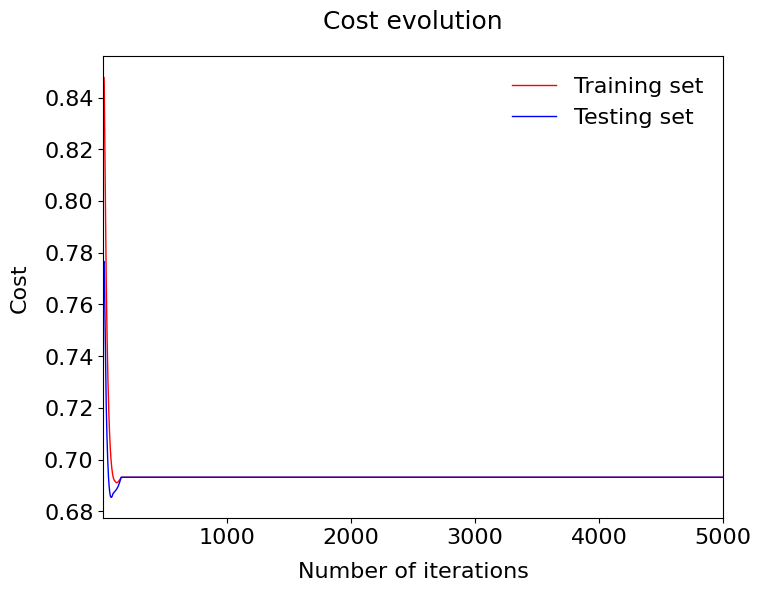

In [83]:
plot_cost_vs_iter(costs_train, costs_test, title="Cost evolution")

### 1.5.2 Scatter Plot

In [84]:
import numpy as np
import pandas as pd
import random
import math
np.random.seed(42)

import matplotlib.pyplot as plt
FONTSIZE = 16
params = {
         'figure.figsize' : (6,6),
         'axes.labelsize' : FONTSIZE,
         'axes.titlesize' : FONTSIZE+2,
         'legend.fontsize': FONTSIZE,
         'xtick.labelsize': FONTSIZE,
         'ytick.labelsize': FONTSIZE,
         'xtick.color'    : 'black',
         'ytick.color'    : 'black',
         'axes.facecolor' : 'white',
         'axes.edgecolor' : 'black',
         'axes.titlepad'  :  20,
         'axes.labelpad'  :  10}
plt.rcParams.update(params)

XNAME = 'x1'; XLABEL = r'$x_1$'
YNAME = 'x2'; YLABEL = r'$x_2$'
RANGE = (-6, 6); STEP = 0.1

In [85]:
def get_decision_surface(weights, biases, boundary=0.5, range=RANGE, step=STEP):

    # Create a grid of points spanning the parameter space:
    x1v, x2v = np.meshgrid(np.arange(range[0], range[1]+step, step),
                           np.arange(range[0], range[1]+step, step)
    )

    # Stack it so that it is shaped like X_train: (m,2)
    X_grid = np.c_[x1v.ravel(), x2v.ravel()].reshape(-1,2)

    # Feedforward on all grid points and get binary predictions:
    output = feedforward(X_grid, weights, biases)[-1] # getting only output node
    Ypred_grid = predict(output, boundary)

    return (x1v, x2v, Ypred_grid.reshape(x1v.shape))



In [86]:
def plot_scatter(sig, bkg, ds=None,
                 xname=XNAME, xlabel=XLABEL,
                 yname=YNAME, ylabel=YLABEL,
                 range=RANGE, step=STEP, title="Scatter plot"):

    fig, ax = plt.subplots()

    # Decision surface
    if ds:
        (xx, yy, Z) = ds # unpack contour data
        cs = plt.contourf(xx, yy, Z, levels=[0,0.5,1], colors=['orange','dodgerblue'], alpha=0.3)

    # Scatter signal and background:
    ax.scatter(sig[xname], sig[yname], marker='o', s=10, c='dodgerblue', alpha=1, label='Positive class')
    ax.scatter(bkg[xname], bkg[yname], marker='o', s=10, c='orange',     alpha=1, label='Negative class')

    # Axes, legend and plot:
    ax.set_xlim(range); ax.set_xlabel(xlabel)
    ax.set_ylim(range); ax.set_ylabel(ylabel)

    ax.legend(bbox_to_anchor=(1.04, 0.5), loc="center left", frameon=False)
    ax.set_title(title)
    plt.show()

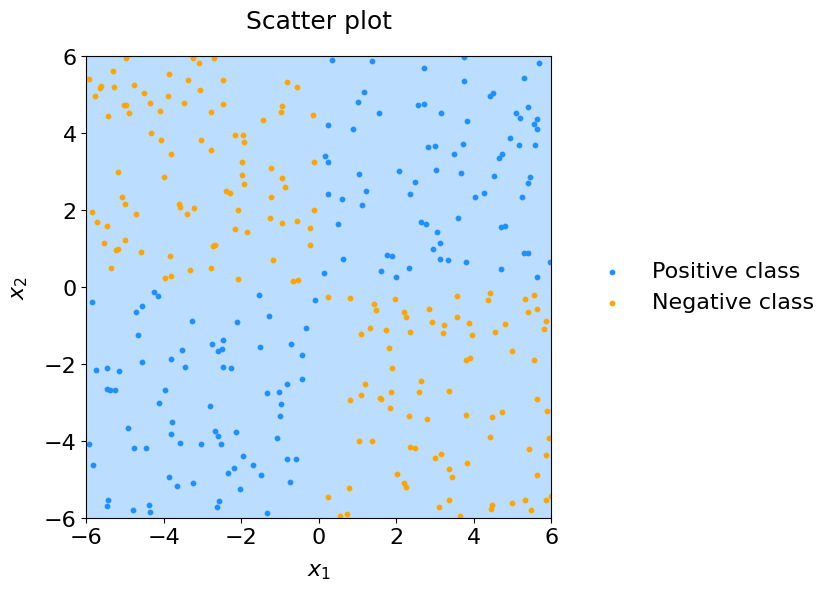

In [87]:
plot_scatter(sig, bkg, ds=get_decision_surface(weights, biases))